# Project 3

## Step 0: Import all functions needed

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')  # Sets the background to white with gridlines
sns.set_context('notebook')  # Adjusts the scale of the plot elements for better readability in notebooks

## Step 1: Load in the data

In [5]:
#### Load in the data in csv
nhts_data = pd.read_csv('NHTS.csv') # importing the national household travel survey
ngsim_data = pd.read_csv('NGSIM.csv') # importing the next generation simulation dataset
 # importing the national household travel survey

nhts_data.columns # to see the column names in the nhts dataset
ngsim_data.columns # to see the column names in the ngsim dataset

Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')

### Bar Chart

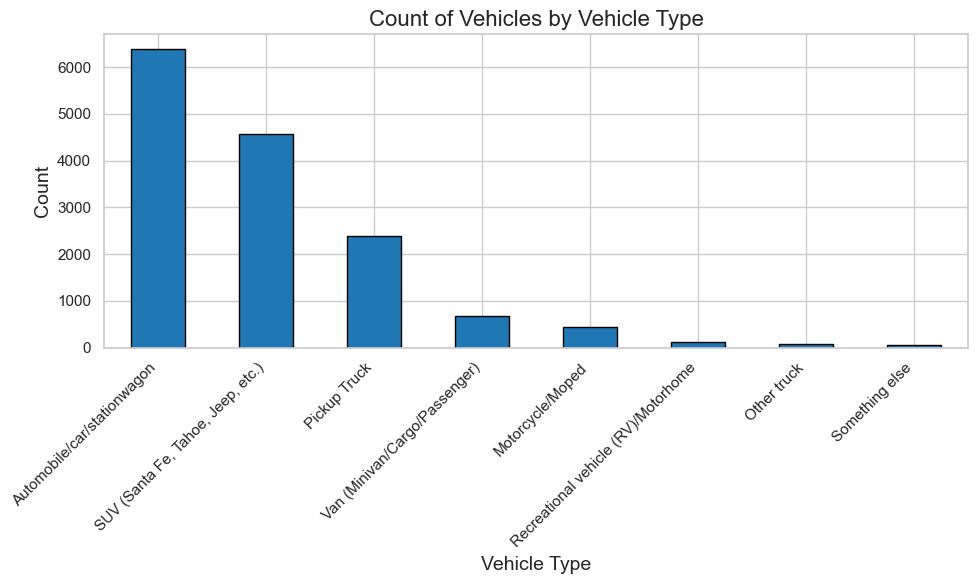

In [8]:
# Count the number of each vehicle type
vehicle_counts = nhts_data['vehicle_type'].value_counts()

# Create a simple bar chart
plt.figure(figsize=(10, 6))
vehicle_counts.plot(kind='bar', edgecolor='black')

plt.title('Count of Vehicles by Vehicle Type', fontsize=16)
plt.xlabel('Vehicle Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Step 3: Histogram

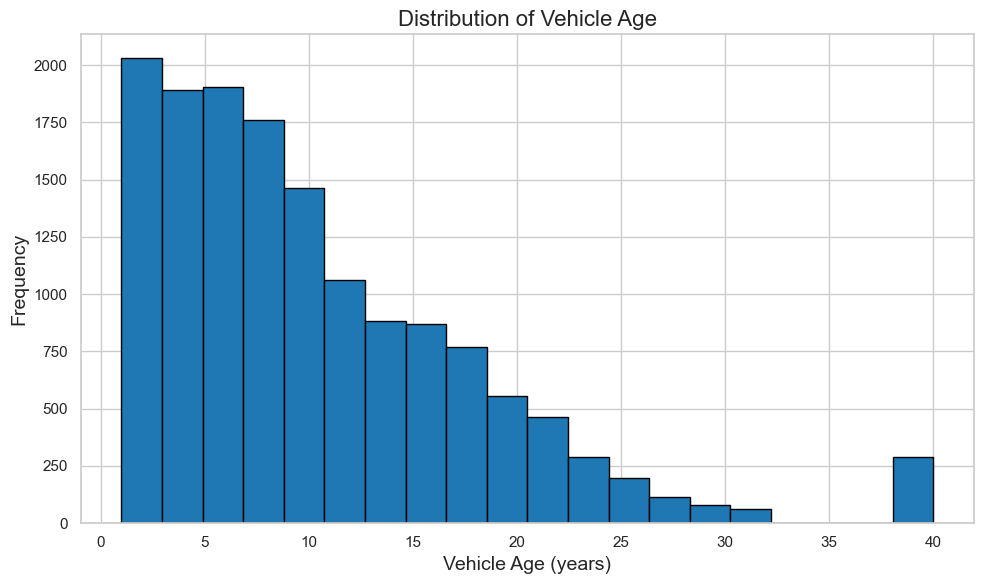

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(nhts_data['vehicle_age'], bins=20, edgecolor='black') # Create a histogram of vehicle age

plt.title('Distribution of Vehicle Age', fontsize=16) # Set the title of the plot
plt.xlabel('Vehicle Age (years)', fontsize=14) # Set the x-axis label
plt.ylabel('Frequency', fontsize=14) # Set the y-axis label
plt.tight_layout() # Adjust the layout to prevent overlap
plt.show() 


## Step 4: Boxplot

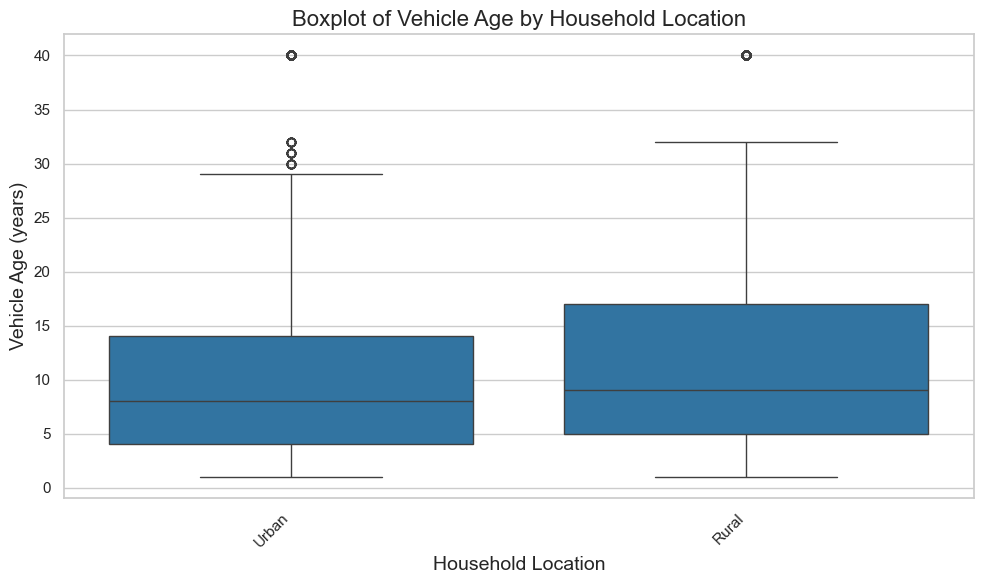

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=nhts_data, x='household_location', y='vehicle_age') # Create a boxplot of vehicle age by household location

plt.title('Boxplot of Vehicle Age by Household Location', fontsize=16) # Set the title of the plot
plt.xlabel('Household Location', fontsize=14) # Set the x-axis label
plt.ylabel('Vehicle Age (years)', fontsize=14) # Set the y-axis label
plt.xticks(rotation=45, ha='right') # Rotate the x-axis labels
plt.tight_layout() # Adjust the layout
plt.show() # Display the plot

## Step 5: Customized Plot



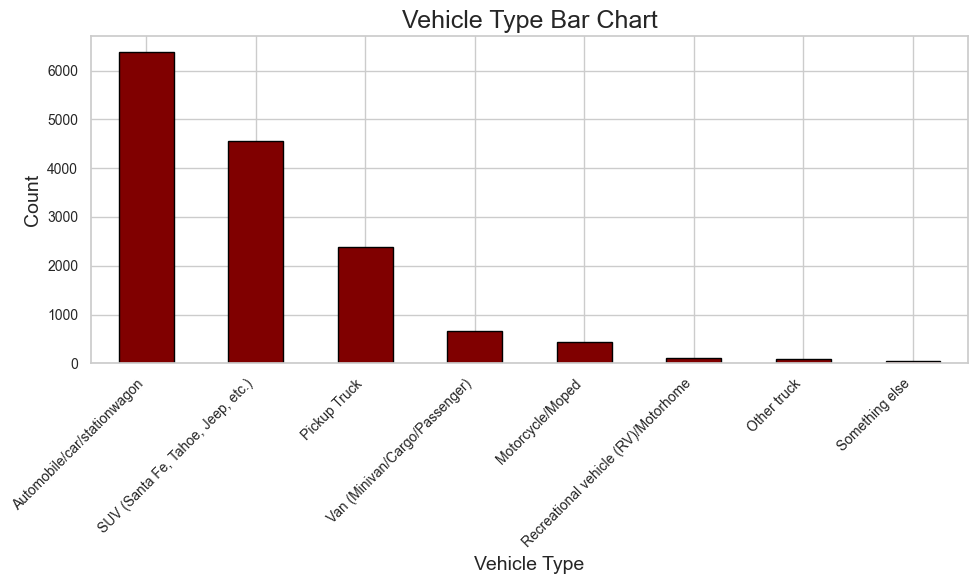

In [18]:
plt.figure(figsize=(10, 6))
vehicle_counts.plot(kind='bar', color='Maroon', edgecolor='black')

plt.title('Vehicle Type Bar Chart', fontsize=18)
plt.xlabel('Vehicle Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## Step 6: Choose a Trajectory

In [19]:
trajectory_number = 2
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].copy()

print("Rows in selected trajectory:", len(data_subset))
print(data_subset.head())

Rows in selected trajectory: 398
     Time  leader_position(m)  follower_position(m)  leader_speed(m/s)  \
841   0.1              18.444                0.0000             13.052   
842   0.2              19.750                1.3716             13.448   
843   0.3              21.094                2.7429             13.777   
844   0.4              22.472                4.1148             13.960   
845   0.5              23.868                5.4861             14.054   

     follower_speed(m/s)  leader_acc(m/s^2)  follower_acc(m/s^2)  \
841               13.716            3.96240             -0.03048   
842               13.713            3.29180              0.06096   
843               13.719            1.82880             -0.06096   
844               13.713            0.94488              0.06096   
845               13.719           -0.03048             -0.06096   

     trajectory_number  
841                  2  
842                  2  
843                  2  
844          

## Step 7: Time-Series plot 1: Position Vs Time

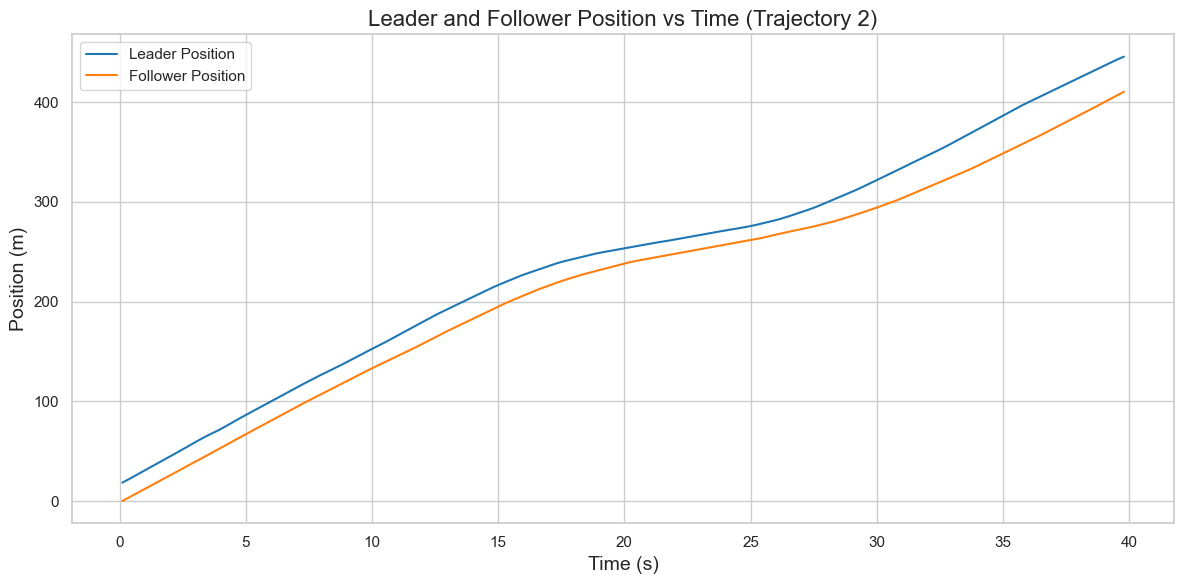

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data_subset, x='Time', y='leader_position(m)', label='Leader Position') # Create a line plot of leader position vs time
sns.lineplot(data=data_subset, x='Time', y='follower_position(m)', label='Follower Position') # Create a line plot of follower position vs time on the same graph

plt.title(f'Leader and Follower Position vs Time (Trajectory {trajectory_number})', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Position (m)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 8 Time-Series plot : Speed vs Time

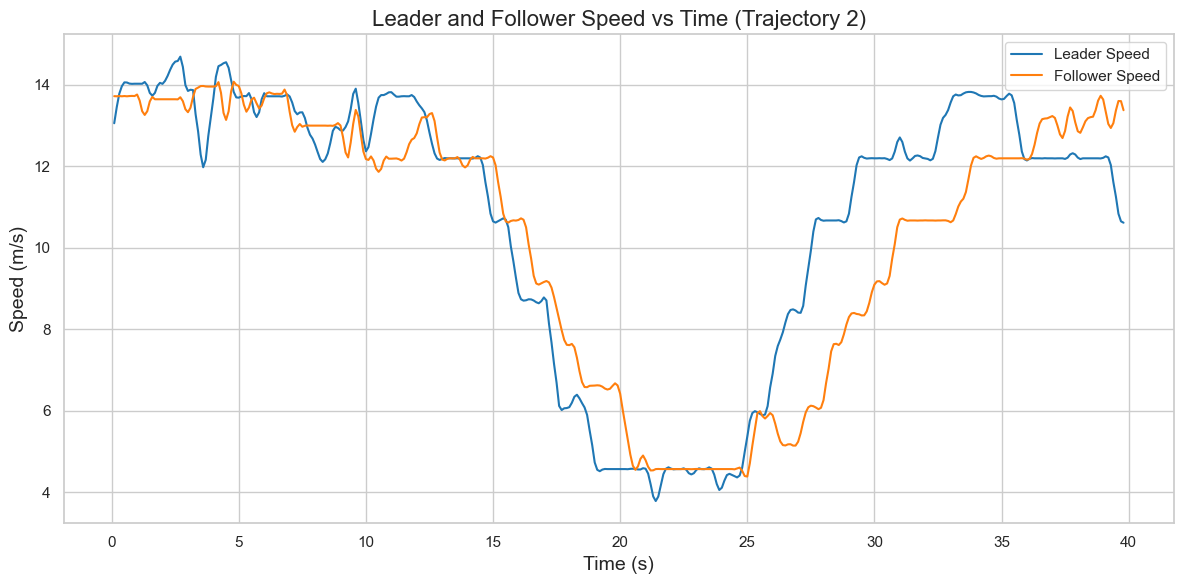

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data_subset, x='Time', y='leader_speed(m/s)', label='Leader Speed')
sns.lineplot(data=data_subset, x='Time', y='follower_speed(m/s)', label='Follower Speed')

plt.title(f'Leader and Follower Speed vs Time (Trajectory {trajectory_number})', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Speed (m/s)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### IDM acceleration function


In [24]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: calculate the desired minimum gap
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))

    # Make sure s_star is not negative
    s_star = max(s_star, s0)

    # Make sure spacing is not zero
    s = max(s, 0.1)

    # Step 2: calculate the IDM acceleration
    acceleration = a * (1 - (v / v0) ** delta - (s_star / s) ** 2)

    return acceleration

## Step 12: Set parameters on the simulation

In [25]:
# Extract arrays from the selected trajectory
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
real_follower_position = data_subset['follower_position(m)'].values
real_follower_speed = data_subset['follower_speed(m/s)'].values
leader_acceleration = data_subset['leader_acc(m/s^2)'].values
real_follower_acceleration = data_subset['follower_acc(m/s^2)'].values

# Time step
dt = np.median(np.diff(time_data))

# IDM parameters
v0 = 30
s0 = 2
T = 1.5
a_param = 1.0
b = 1.5
delta = 4

# Initialize arrays
n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acceleration = np.zeros(n_steps)

# Start the simulation at the real follower's initial state
sim_position[0] = real_follower_position[0]
sim_speed[0] = real_follower_speed[0]

## Step 13: Run the IDM simulation 

In [26]:
for i in range(n_steps - 1):
    # Calculate gap between leader and simulated follower
    gap = max(leader_position[i] - sim_position[i], 0.1)

    # Speed difference = follower speed - leader speed
    delta_v = sim_speed[i] - leader_speed[i]

    # IDM acceleration
    sim_acceleration[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    # Update speed and position
    sim_speed[i + 1] = max(0, sim_speed[i] + sim_acceleration[i] * dt)
    sim_position[i + 1] = sim_position[i] + sim_speed[i] * dt

# Fill in the last acceleration value
sim_acceleration[-1] = sim_acceleration[-2]

print("Simulation complete.")


Simulation complete.


## Step 14 Acceleration comparison plot

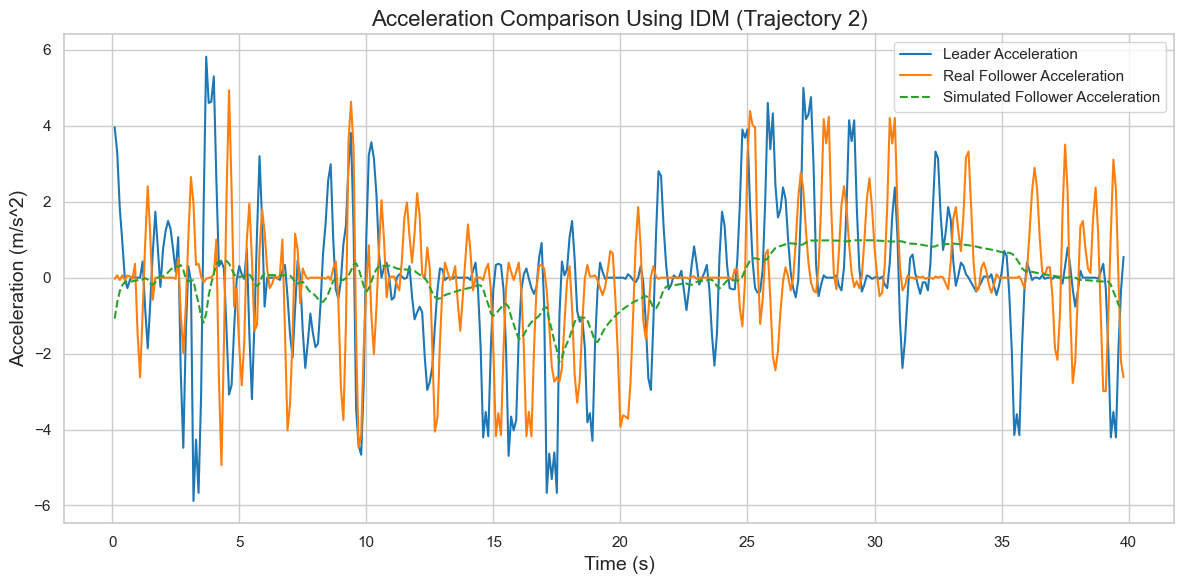

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(time_data, leader_acceleration, label='Leader Acceleration')
plt.plot(time_data, real_follower_acceleration, label='Real Follower Acceleration')
plt.plot(time_data, sim_acceleration, label='Simulated Follower Acceleration', linestyle='--')

plt.title(f'Acceleration Comparison Using IDM (Trajectory {trajectory_number})', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Acceleration (m/s^2)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 15 Line comparison plot 

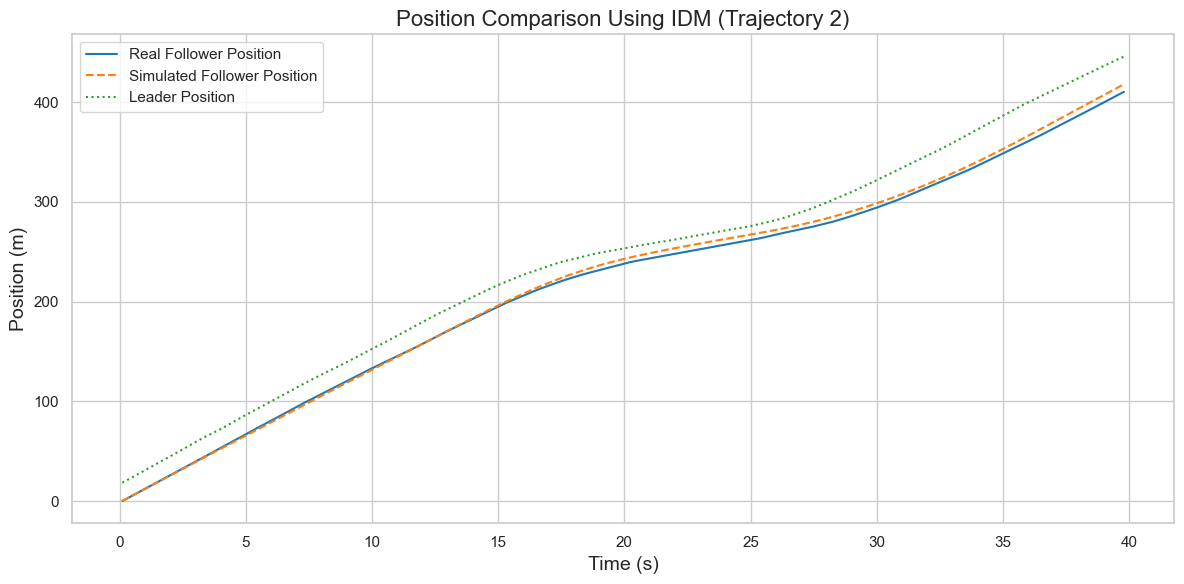

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(time_data, real_follower_position, label='Real Follower Position')
plt.plot(time_data, sim_position, label='Simulated Follower Position', linestyle='--')
plt.plot(time_data, leader_position, label='Leader Position', linestyle=':')

plt.title(f'Position Comparison Using IDM (Trajectory {trajectory_number})', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Position (m)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()